# Tree counting and crown segmentation from aerial imagery — pretrained inference on the authors' 1 km example tile

Reproduction of the pretrained-inference example from:
**Li, S., et al. (2023). "Deep learning enables image-based tree counting, crown segmentation, and height prediction at national scale." *PNAS Nexus* 2(4), pgad076.** [DOI: 10.1093/pnasnexus/pgad076](https://doi.org/10.1093/pnasnexus/pgad076)

Author code: [`sizhuoli/TreeCountSegHeight`](https://github.com/sizhuoli/TreeCountSegHeight) @ commit `6cab24dad58ffcdb5afb2417b49826e643561fac` (branch `main`, Feb 2025 structure).

**Scope (partial demonstration).** We run the authors' pretrained RGB counting+segmentation model on the 1×1 km Danish example tile shipped in the repository (`example_1km_tile_tif/2018_1km_6238_592.tif`, 20 cm RGB+NIR, 5000×5000 px) and compare our outputs with the reference predictions the authors ship next to it (`predictions/2018_1km_6238_592_seg.tif`, `..._density.tif`). This is the exact example the README documents for `main4_large_scale_inference_transfer_other_data.py` with `config/RasterAnalysis.py`. Paper-level national-scale results, training, fine-tuning, and the **height-prediction model are out of scope** (the shipped example contains no height product).

**AI-assisted port.** The model definition and inference loop are the authors' own code (copied from the pinned commit); the only code change is a one-line Keras 3 compatibility patch (`get_shape().as_list()[3]` → `shape[3]`), documented at the definition. The authors did not provide this Colab notebook.

**日本語概要:** 著者提供の学習済み RGB モデル（樹木計数＋樹冠セグメンテーション）を、リポジトリ同梱のデンマーク 1×1 km 例題タイル（20 cm 解像度）に実行し、著者が同梱する参照予測（seg / density GeoTIFF）と比較します。学習・再学習・高さ推定モデルは範囲外です。モデル定義と推論ループは著者コードのコピーで、Keras 3 対応の 1 行修正のみ加えています。


## Runtime selection & how to run

**Recommended: GPU runtime (Runtime ▸ Change runtime type ▸ T4 GPU).** The authors ran inference on GPU; on T4 the full-tile inference takes a few minutes. A **CPU runtime also works with this same notebook** (verified at cell level during pre-validation probes: weight loading and inference run unchanged on CPU; batch size is lowered automatically), but the sliding-window inference over 529 overlapping 256×256 patches takes roughly 20–60 minutes on the free 2-vCPU runtime.

**Run all:** `Runtime ▸ Run all`. Downloads: ~1.4 GB total (pretrained-weights zip 1.04 GB from the authors' ERDA share, example tile 20 MB, reference predictions 36 MB from the pinned GitHub commit). Nothing is written outside `/content`.

**日本語:** 推奨ランタイムは T4 GPU です（数分で完了）。CPU でも動作しますが、推論に 20〜60 分程度かかります。「ランタイム ▸ すべてのセルを実行」でそのまま実行できます。合計約 1.4 GB をダウンロードします。


## 1. Environment setup

We check TensorFlow/Keras versions and the allocated device, and install `rasterio` (GeoTIFF I/O; the authors' code uses it). Everything else is preinstalled on Colab. The batch size is the only resource-dependent setting: pure inference per 256×256 patch is independent of batching, so this changes speed only, not results (adaptation of `config/RasterAnalysis.py`'s `BATCH_SIZE = 128`, which assumes ≥16 GB GPU memory; T4 has 15 GB).


In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import sys, time
import numpy as np
import tensorflow as tf

t0_notebook = time.time()
gpus = tf.config.list_physical_devices("GPU")
BATCH_SIZE = 32 if gpus else 16   # author default 128; lowered for 15 GB T4 / CPU RAM (no effect on outputs)
print("Python", sys.version.split()[0])
print("TensorFlow", tf.__version__, "| Keras", tf.keras.__version__)
print("GPUs:", gpus)
print("BATCH_SIZE =", BATCH_SIZE)
if not gpus:
    print("WARNING: no GPU allocated. The notebook will still run faithfully on CPU, but the full-tile inference will take tens of minutes.")

!pip install -q rasterio
import rasterio
print("rasterio", rasterio.__version__)


Python 3.13.15
TensorFlow 2.21.0 | Keras 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
BATCH_SIZE = 32


rasterio 1.5.2


## 2. Pretrained weights download (Colab-only)

The authors' `ModelManager.download_weights` (`core2/model_manager.py:86`) downloads the model archive from their ERDA share
`https://sid.erda.dk/share_redirect/gS7JX84yvu` and extracts it. We do the same and keep only the RGB model named in the
authors' example config (`config/RasterAnalysis.py`):
`trees_20210620-0202_Adam_e4_redgreenblue_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5`.
The archive ships no published checksum, so we validate it by full ZIP CRC test and by the exact member name.


In [ ]:
import urllib.request, pathlib, zipfile, time

WEIGHTS_URL = "https://sid.erda.dk/share_redirect/gS7JX84yvu"
RGB_H5_NAME = "trees_20210620-0202_Adam_e4_redgreenblue_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5"
zip_path = pathlib.Path("/content/weights/gS7JX84yvu.zip")
zip_path.parent.mkdir(parents=True, exist_ok=True)

if not zip_path.exists():
    t0 = time.time()
    last = [0]
    def hook(n, bs, total):
        done = n * bs
        if done - last[0] > 200e6:
            last[0] = done
            print(f"  {done/1e6:.0f} MB ({time.time()-t0:.0f}s)", flush=True)
    urllib.request.urlretrieve(WEIGHTS_URL, zip_path, reporthook=hook)
    print(f"downloaded {zip_path.stat().st_size:,} bytes in {time.time()-t0:.0f}s")
else:
    print("zip already present:", zip_path.stat().st_size, "bytes")

with zipfile.ZipFile(zip_path) as z:
    assert z.testzip() is None, "ZIP CRC check failed"
    members = z.infolist()
    print("zip OK:", len(members), "entries:", [m.filename for m in members])
    h5_member = next(m for m in members if m.filename.endswith(RGB_H5_NAME))
    h5_member_size = h5_member.file_size
    z.extract(h5_member, "/content/weights/")
h5_path = next(pathlib.Path("/content/weights").rglob(RGB_H5_NAME))
print("RGB model ready:", h5_path, f"({h5_path.stat().st_size:,} bytes)")


  200 MB (19s)


  400 MB (34s)


  600 MB (48s)


  800 MB (63s)


  1000 MB (81s)


downloaded 1,040,851,361 bytes in 84s


zip OK: 5 entries: ['saved_models/', 'saved_models/trees_20210708-0024_Adam_e4_redgreenblueinfraredndvi_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5', 'saved_models/trees_20210619-0148_Adam_e4_redgreenblueinfrared_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5', 'saved_models/trees_20210620-0202_Adam_e4_redgreenblue_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5', 'saved_models/readme.md']


RGB model ready: /content/weights/saved_models/trees_20210620-0202_Adam_e4_redgreenblue_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5 (383,306,456 bytes)


## 3. Example tile, reference predictions, and data license (Colab-only)

These are dataset bytes, so they are fetched here inside Colab from the pinned author commit
`6cab24dad58ffcdb5afb2417b49826e643561fac` via raw.githubusercontent.com, and each file is verified against the
git blob SHA-1 recorded in the repository tree (`git hash-object` equivalent), so any byte corruption is caught.
The tile is a 5000×5000 px, 4-band (R,G,B,NIR) uint8 GeoTIFF at 0.2 m (EPSG:25832). We also print the authors'
example-data license note.


In [ ]:
import hashlib

PIN = "6cab24dad58ffcdb5afb2417b49826e643561fac"
BASE = f"https://raw.githubusercontent.com/sizhuoli/TreeCountSegHeight/{PIN}/"
EXPECTED = {  # path -> (size, git blob sha1) from the pinned repository tree
    "example_1km_tile_tif/2018_1km_6238_592.tif":
        (19862219, "342c10f61caabb1bb350bef0a6292bf45d13b079"),
    "example_1km_tile_tif/predictions/2018_1km_6238_592_seg.tif":
        (1598939, "f20206e3588406be06521e2a5aa83a4592dd2822"),
    "example_1km_tile_tif/predictions/2018_1km_6238_592_density.tif":
        (34486051, "3a23225f1b39ba289670f75d18adaf3560accf4a"),
    "example_extracted_data/IMPORTANT_LISCENCE_ISSUE_Data_usage_license_read_me.md":
        (48, None),
}

def blob_sha1(p):
    data = pathlib.Path(p).read_bytes()
    h = hashlib.sha1()
    h.update(f"blob {len(data)}\x00".encode())
    h.update(data)
    return h.hexdigest()

for rel, (size, sha) in EXPECTED.items():
    out = pathlib.Path("/content") / rel
    out.parent.mkdir(parents=True, exist_ok=True)
    if not out.exists() or out.stat().st_size != size:
        urllib.request.urlretrieve(BASE + rel, out)
    got = blob_sha1(out)
    status = "sha1 OK" if (sha is None or got == sha) else f"SHA MISMATCH ({got})"
    print(f"{rel}: {out.stat().st_size:,} B  {status}")

TILE = "/content/example_1km_tile_tif/2018_1km_6238_592.tif"
REF_SEG = "/content/example_1km_tile_tif/predictions/2018_1km_6238_592_seg.tif"
REF_DENS = "/content/example_1km_tile_tif/predictions/2018_1km_6238_592_density.tif"
print()
print(pathlib.Path("/content/example_extracted_data/IMPORTANT_LISCENCE_ISSUE_Data_usage_license_read_me.md").read_text())


example_1km_tile_tif/2018_1km_6238_592.tif: 19,862,219 B  sha1 OK


example_1km_tile_tif/predictions/2018_1km_6238_592_seg.tif: 1,598,939 B  sha1 OK


example_1km_tile_tif/predictions/2018_1km_6238_592_density.tif: 34,486,051 B  sha1 OK
example_extracted_data/IMPORTANT_LISCENCE_ISSUE_Data_usage_license_read_me.md: 48 B  sha1 OK

See updated data availability in main readme.md



## 4. Input preview — the example tile and the authors' reference outputs

Before running any model we look at the actual inputs: (a) the RGB view of the 1 km tile, (b) the authors' reference
crown segmentation (`*_seg.tif`, uint8 0/1) drawn over it, and (c) the authors' reference tree-density map
(`*_density.tif`, float32; brighter = higher density). These reference rasters are the comparison target for this
reproduction — they were produced by the authors' RGB model on this tile.


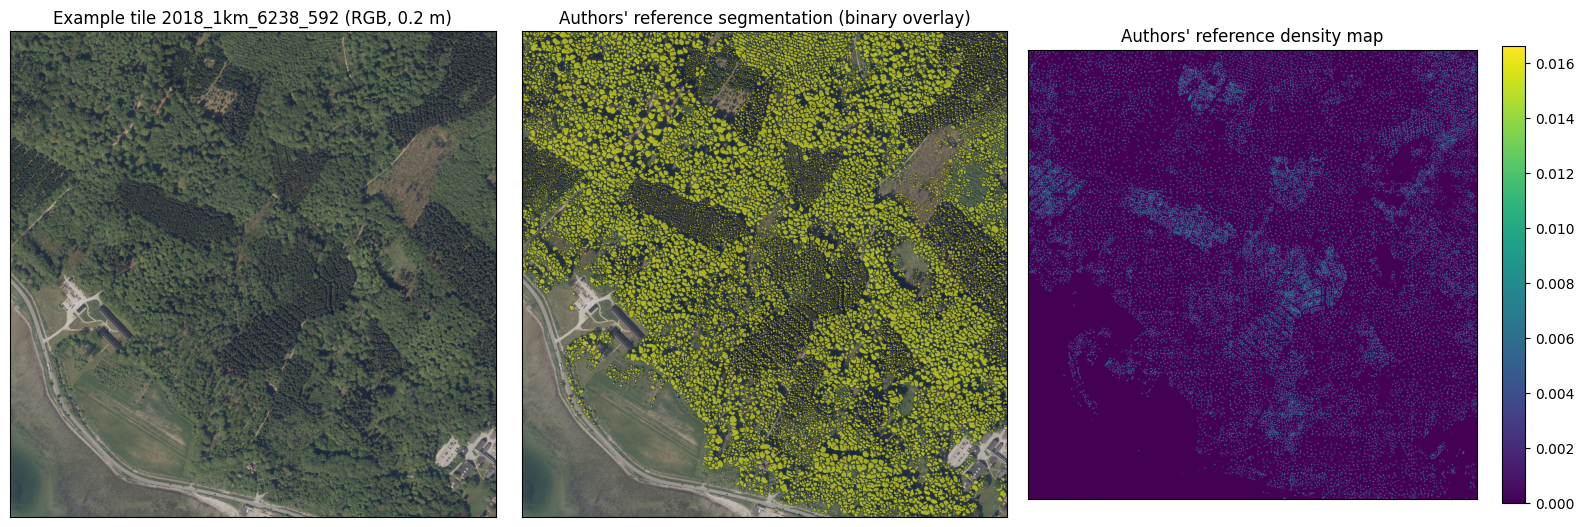

reference seg: dtype uint8 | crown pixels: 9948654
reference density: dtype float32 | max 0.017970 | sum (tree count) 18871.12


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors

with rasterio.open(TILE) as ds:
    tile_meta = ds.meta
    out_crs, out_transform = ds.crs, ds.transform
    rgb_small = ds.read([1, 2, 3], out_shape=(3, 1250, 1250))
with rasterio.open(REF_SEG) as ds:
    seg_small = ds.read(1, out_shape=(ds.height // 4, ds.width // 4))
with rasterio.open(REF_DENS) as ds:
    dens_small = ds.read(1, out_shape=(ds.height // 4, ds.width // 4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
axes[0].imshow(np.transpose(rgb_small, (1, 2, 0)))
axes[0].set_title("Example tile 2018_1km_6238_592 (RGB, 0.2 m)")
axes[1].imshow(np.transpose(rgb_small, (1, 2, 0)))
axes[1].imshow(np.ma.masked_where(seg_small == 0, seg_small), cmap="autumn_r", alpha=0.5)
axes[1].set_title("Authors' reference segmentation (binary overlay)")
im = axes[2].imshow(dens_small, cmap="viridis")
axes[2].set_title("Authors' reference density map")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.savefig("/content/input_and_reference.png", dpi=110, bbox_inches="tight")
plt.show()

ref_seg = rasterio.open(REF_SEG).read(1)
ref_dens = rasterio.open(REF_DENS).read(1)
print("reference seg: dtype", ref_seg.dtype, "| crown pixels:", int(ref_seg.sum()))
print("reference density: dtype", ref_dens.dtype, "| max %.6f | sum (tree count) %.2f" % (ref_dens.max(), ref_dens.sum()))


## 5. Author model definition (copied from the pinned commit)

Verbatim from `core2/UNet_attention_segcount.py` (attention U-Net with two heads: `output_seg` sigmoid, `output_dens` linear).
**One documented compatibility change:** `attention_up_and_concate` used `down_layer.get_shape().as_list()[3]`, which Keras 3
(Colab: TensorFlow 2.21 / Keras 3.13) removed from `KerasTensor`; it is replaced by the equivalent `down_layer.shape[3]`.
Nothing else is altered.

**日本語:** モデル定義は著者コードのコピーです。Keras 3 で `get_shape()` が使えなくなったため、同義の `shape[3]` への 1 行修正のみ行っています。


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

def attention_up_and_concate(down_layer, layer):
    in_channel = down_layer.shape[3]  # COMPAT PATCH (Keras 3): was down_layer.get_shape().as_list()[3]
    up = layers.UpSampling2D(size=(2, 2))(down_layer)
    layer = attention_block_2d(x=layer, g=up, inter_channel=in_channel // 4)
    my_concat = layers.Lambda(lambda x: K.concatenate([x[0], x[1]], axis=3))
    concate = my_concat([up, layer])
    return concate

def attention_block_2d(x, g, inter_channel):
    theta_x = layers.Conv2D(inter_channel, [1, 1], strides=[1, 1])(x)
    phi_g = layers.Conv2D(inter_channel, [1, 1], strides=[1, 1])(g)
    f = layers.Activation('relu')(layers.add([theta_x, phi_g]))
    psi_f = layers.Conv2D(1, [1, 1], strides=[1, 1])(f)
    rate = layers.Activation('sigmoid')(psi_f)
    att_x = layers.multiply([x, rate])
    return att_x

def UNet(input_shape, input_label_channel=1, layer_count=64,
         regularizers=regularizers.l2(0.0001), gaussian_noise=0.1,
         weight_file=None, inputBN=0):
    # (batch, height, width, channels); batch entry is unused by layers.Input
    input_img1 = layers.Input((input_shape[1], input_shape[2], input_shape[3]), name='Input1')
    input_img2 = input_img1 if not inputBN else layers.BatchNormalization()(input_img1)
    c11 = layers.Conv2D(1*layer_count, (3, 3), activation='relu', padding='same')(input_img2)
    c110 = layers.Conv2D(1*layer_count, (3, 3), activation='relu', padding='same')(c11)
    n11 = layers.BatchNormalization()(c110)
    p11 = layers.MaxPooling2D((2, 2))(n11)
    c2 = layers.Conv2D(2*layer_count, (3, 3), activation='relu', padding='same')(p11)
    c2 = layers.Conv2D(2*layer_count, (3, 3), activation='relu', padding='same')(c2)
    n2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(n2)
    c3 = layers.Conv2D(4*layer_count, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(4*layer_count, (3, 3), activation='relu', padding='same')(c3)
    n3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(n3)
    c4 = layers.Conv2D(8*layer_count, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(8*layer_count, (3, 3), activation='relu', padding='same')(c4)
    n4 = layers.BatchNormalization()(c4)
    p4 = layers.MaxPooling2D(pool_size=(2, 2))(n4)
    c5 = layers.Conv2D(16*layer_count, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(16*layer_count, (3, 3), activation='relu', padding='same')(c5)
    n5 = layers.BatchNormalization()(c5)
    u6 = attention_up_and_concate(n5, n4)
    c6 = layers.Conv2D(8*layer_count, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(8*layer_count, (3, 3), activation='relu', padding='same')(c6)
    n6 = layers.BatchNormalization()(c6)
    u7 = attention_up_and_concate(n6, n3)
    c7 = layers.Conv2D(4*layer_count, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(4*layer_count, (3, 3), activation='relu', padding='same')(c7)
    n7 = layers.BatchNormalization()(c7)
    u8 = attention_up_and_concate(n7, n2)
    c8 = layers.Conv2D(2*layer_count, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(2*layer_count, (3, 3), activation='relu', padding='same')(c8)
    n8 = layers.BatchNormalization()(c8)
    u9 = attention_up_and_concate(n8, n11)
    c9 = layers.Conv2D(1*layer_count, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(1*layer_count, (3, 3), activation='relu', padding='same')(c9)
    n9 = layers.BatchNormalization()(c9)
    d = layers.Conv2D(input_label_channel, (1, 1), activation='sigmoid',
                      kernel_regularizer=regularizers, name='output_seg')(n9)
    d2 = layers.Conv2D(input_label_channel, (1, 1), activation='linear',
                       kernel_regularizer=regularizers, name='output_dens')(n9)
    seg_model = models.Model(inputs=[input_img1], outputs=[d, d2])
    if weight_file:
        seg_model.load_weights(weight_file)
    return seg_model

model = UNet([BATCH_SIZE, 256, 256, 3], inputBN=False)
print("parameters:", model.count_params())


parameters: 31914470


## 6. Load the pretrained weights and switch to inference mode

Exactly as in `ModelManager.load_model` (`core2/model_manager.py:74`): `load_weights` on the `.h5` archive member,
then `trainable = False`. We do not `compile` (not needed for inference; that also avoids pulling in the training
losses). Keras 3 loads the legacy `.h5` weights written by the authors' TensorFlow 2.15 environment directly.


In [ ]:
model.load_weights(str(h5_path))
model.trainable = False
print("weights loaded from", h5_path.name)


weights loaded from trees_20210620-0202_Adam_e4_redgreenblue_256_84_frames_weightmapTversky_MSE100_5weight_attUNet.h5


## 7. Sliding-window inference over the 1 km tile (authors' algorithm, ported 1:1)

Faithful port of `detect_tree_segcount_fi` + `predict_using_model_segcount_fi` + `addTOResult`
(`core2/raster_ana_segcount.py:360-465`, `core2/model_manager.py:171-239`) with the example config
`config/RasterAnalysis.py`: 256×256 patches, **stride 224** (32 px overlap), per-patch channel-wise standardization
`image_normalize` (`core2/frame_info.py:6`: `(im - mean)/std` with `c=1e-8`, per RGB channel inside each patch),
RGB = bands 0/1/2, MAX merging of overlapping predictions, batched `model.predict`.
Border patches are zero-padded after normalizing the valid window, exactly as in the author code. Only the unused
`workers`/`use_multiprocessing` arguments of `model.predict` are dropped (single process; no effect on outputs).

**日本語:** 著者の推論ループ（256×256 パッチ、ストライド 224、パッチ毎のチャネル別標準化、重複領域は MAX 結合）をそのまま移植しています。バッチサイズのみハードウェアに合わせて調整します（結果に影響しません）。


In [ ]:
from itertools import product
import rasterio.windows as windows

STRIDE, WIDTH, HEIGHT = 224, 256, 256  # config/RasterAnalysis.py
assert WIDTH == HEIGHT == model.inputs[0].shape[1] == 256

def image_normalize(im, axis=(0, 1), c=1e-8):
    # core2/frame_info.py:6-9
    return (im - im.mean(axis)) / (im.std(axis) + c)

def add_to_result(res, prediction, row, col, he, wi):
    # addTOResult with operator='MAX' (core2/model_manager.py:171-193)
    curr = res[row:row+he, col:col+wi]
    res[row:row+he, col:col+wi] = np.maximum(curr, prediction[:he, :wi])
    return res

def predict_batch(batch, batch_pos, maskseg, maskdens):
    # predict_using_model_segcount_fi, rgb branch (raster_ana_segcount.py)
    tm1 = np.stack(batch, axis=0)
    seg, dens = model.predict(tm1, verbose=0)
    for i, (col, row, wi, he) in enumerate(batch_pos):
        p = np.squeeze(seg[i], axis=-1)
        c = np.squeeze(dens[i], axis=-1)
        maskseg = add_to_result(maskseg, p, row, col, he, wi)
        maskdens = add_to_result(maskdens, c, row, col, he, wi)
    return maskseg, maskdens

with rasterio.open(TILE) as img:
    nols, nrows = img.meta['width'], img.meta['height']
    # prediction dtype is float (author comment); a clean profile avoids the tile's JPEG-incompatible extras
    out_dtype = 'float32'
    offsets = list(product(range(0, nols, STRIDE), range(0, nrows, STRIDE)))
    big_window = windows.Window(col_off=0, row_off=0, width=nols, height=nrows)
    maskseg = np.zeros((nrows, nols), dtype=np.float32)
    maskdens = np.zeros((nrows, nols), dtype=np.float32)

    batch, batch_pos = [], []
    t0 = time.time()
    for k, (col_off, row_off) in enumerate(offsets):
        window = windows.Window(col_off=col_off, row_off=row_off,
                                width=WIDTH, height=HEIGHT).intersection(big_window)
        temp_im1 = img.read(window=window)
        temp_im1 = np.transpose(temp_im1, axes=(1, 2, 0))[:, :, [0, 1, 2]].astype(np.float32)
        temp_im1 = image_normalize(temp_im1, axis=(0, 1))  # per-patch, per-RGB-channel
        patch1 = np.zeros((HEIGHT, WIDTH, 3), dtype=np.float32)  # zero-pad borders
        patch1[:int(window.height), :int(window.width)] = temp_im1
        batch.append(patch1)
        batch_pos.append((window.col_off, window.row_off, window.width, window.height))
        if len(batch) == BATCH_SIZE:
            maskseg, maskdens = predict_batch(batch, batch_pos, maskseg, maskdens)
            print(f"  batch {k//BATCH_SIZE+1}/{(len(offsets)+BATCH_SIZE-1)//BATCH_SIZE} done ({time.time()-t0:.0f}s)", flush=True)
            batch, batch_pos = [], []
    if batch:
        maskseg, maskdens = predict_batch(batch, batch_pos, maskseg, maskdens)
inference_s = time.time() - t0
print(f"inference done: {len(offsets)} patches in {inference_s:.0f}s")


  batch 1/17 done (12s)


  batch 2/17 done (13s)


  batch 3/17 done (13s)


  batch 4/17 done (14s)


  batch 5/17 done (15s)


...

  batch 13/17 done (20s)


  batch 14/17 done (21s)


  batch 15/17 done (21s)


  batch 16/17 done (22s)


inference done: 529 patches in 30s


## 8. Threshold, export GeoTIFFs, and count trees

Exactly as `writeMaskToDisk` is called in the authors' example path: segmentation thresholded at **0.5 → uint8 {0,1}**,
density written as **raw float32** (no threshold), both LZW-compressed with the tile's georeferencing
(EPSG:25832, 0.2 m). Tree count follows the authors' `integrate_count` (`core2/model_compare.py:527`):
clip negative density values to 0, then sum the density map.


In [ ]:
SEG_TH = 0.5  # config/RasterAnalysis.py threshold
pred_seg = np.where(maskseg < SEG_TH, 0, 1).astype("uint8")   # author: detected_mask[<th]=0, [>=th]=1
pred_dens = maskdens.astype("float32")

pred_seg_path = "/content/predictions/2018_1km_6238_592_seg.tif"
pred_dens_path = "/content/predictions/2018_1km_6238_592_density.tif"
pathlib.Path("/content/predictions").mkdir(exist_ok=True)
write_profile = {"driver": "GTiff", "width": nols, "height": nrows, "count": 1,
                 "crs": out_crs, "transform": out_transform,
                 "compress": "lzw", "nodata": 255}
with rasterio.open(pred_seg_path, "w", dtype="uint8", **write_profile) as outds:
    outds.write(pred_seg, 1)
with rasterio.open(pred_dens_path, "w", dtype="float32", **write_profile) as outds:
    outds.write(pred_dens, 1)

pred_count = float(np.clip(pred_dens, 0, None).sum())   # integrate_count: clip negatives, sum
ref_count = float(np.clip(ref_dens, 0, None).sum())
print(f"predicted tree count (density sum): {pred_count:.2f}")
print(f"reference tree count (density sum): {ref_count:.2f}")


predicted tree count (density sum): 18871.34
reference tree count (density sum): 18871.12


## 9. Quantitative comparison with the authors' stored example predictions

Same model, same input, same recipe — so on identical hardware the maps would be near-identical; small numeric
differences remain because the reference was produced with the authors' TensorFlow 2.15 GPU stack and this notebook
runs TensorFlow 2.21 (CPU or T4). Metrics: Pearson correlation and MAE between the two density maps; IoU and pixel
agreement between the binary segmentation maps; relative difference of the density-sum tree counts. The small table
is also exported as CSV inside this Colab VM (`/content/comparison_metrics.csv`).


In [ ]:
import pandas as pd

flat_p, flat_r = pred_dens.ravel(), ref_dens.ravel()
corr = float(np.corrcoef(flat_p, flat_r)[0, 1])
mae = float(np.abs(flat_p - flat_r).mean())
inter = int(np.logical_and(pred_seg == 1, ref_seg == 1).sum())
union = int(np.logical_or(pred_seg == 1, ref_seg == 1).sum())
iou = inter / union
agree = float((pred_seg == ref_seg).mean())
metrics = pd.DataFrame([
    {"metric": "tree count (density sum)", "this notebook": pred_count, "authors' reference": ref_count},
    {"metric": "density Pearson r", "this notebook": corr, "authors' reference": 1.0},
    {"metric": "density MAE", "this notebook": mae, "authors' reference": 0.0},
    {"metric": "segmentation IoU", "this notebook": iou, "authors' reference": 1.0},
    {"metric": "segmentation pixel agreement", "this notebook": agree, "authors' reference": 1.0},
])
metrics.to_csv("/content/comparison_metrics.csv", index=False)
print(metrics.to_string(index=False))


                      metric  this notebook  authors' reference
    tree count (density sum)   1.887134e+04        18871.123047
           density Pearson r   1.000000e+00            1.000000
                 density MAE   4.216474e-08            0.000000
            segmentation IoU   9.999974e-01            1.000000
segmentation pixel agreement   9.999990e-01            1.000000


## 10. Visual comparison — input, authors' reference, and this run

The panel shows (a) the input RGB tile, (b) the authors' stored segmentation overlaid, (c) this notebook's predicted
segmentation overlaid, using the identical overlay style so differences are visible. The scatter/diff panel compares
the density maps pixel-by-pixel. All imagery in these panels comes from the downloaded example tile and the run's own
outputs; nothing is copied from the paper's figures.


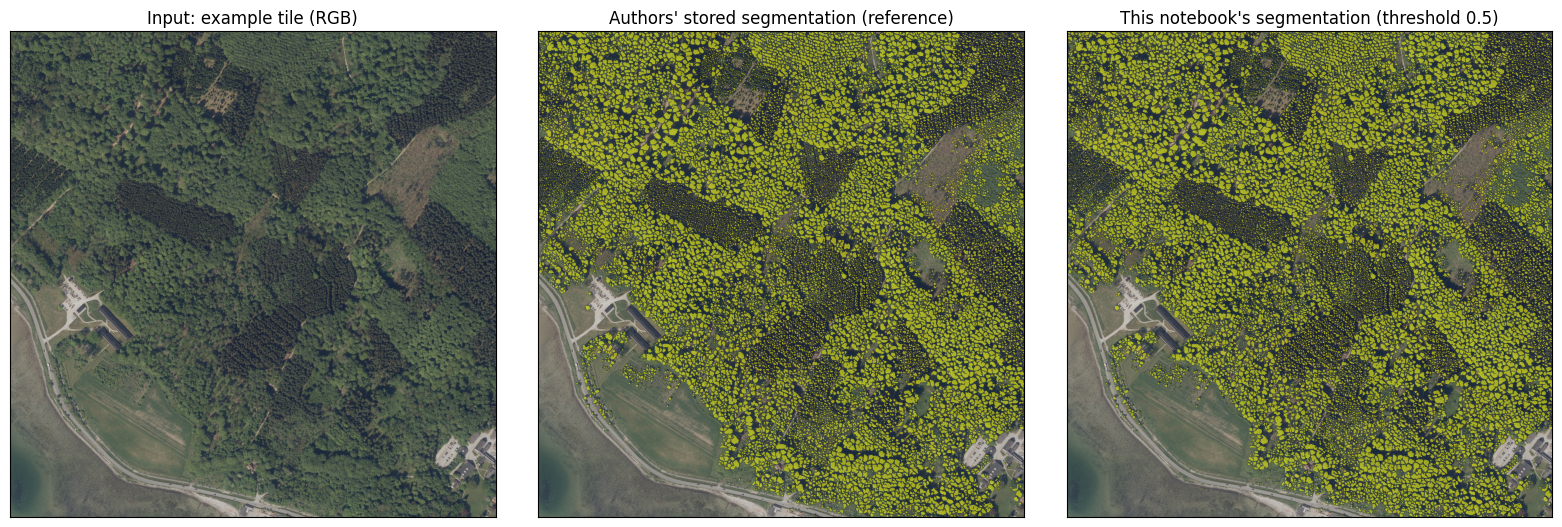

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
axes[0].imshow(np.transpose(rgb_small, (1, 2, 0)))
axes[0].set_title("Input: example tile (RGB)")
axes[1].imshow(np.transpose(rgb_small, (1, 2, 0)))
axes[1].imshow(np.ma.masked_where(seg_small == 0, seg_small), cmap="autumn_r", alpha=0.5)
axes[1].set_title("Authors' stored segmentation (reference)")
axes[2].imshow(np.transpose(rgb_small, (1, 2, 0)))
axes[2].imshow(np.ma.masked_where(pred_seg[::4, ::4] == 0, pred_seg[::4, ::4]), cmap="autumn_r", alpha=0.5)
axes[2].set_title("This notebook's segmentation (threshold 0.5)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("/content/comparison_seg.png", dpi=110, bbox_inches="tight")
plt.show()


## 11. Density-map agreement (scatter and difference)

A pixel-scatter of predicted vs reference density and the signed difference map. This graph is generated here for
this notebook (the paper does not publish it); it only quantifies reproduction fidelity on this single tile and does
not imply any paper-level accuracy.


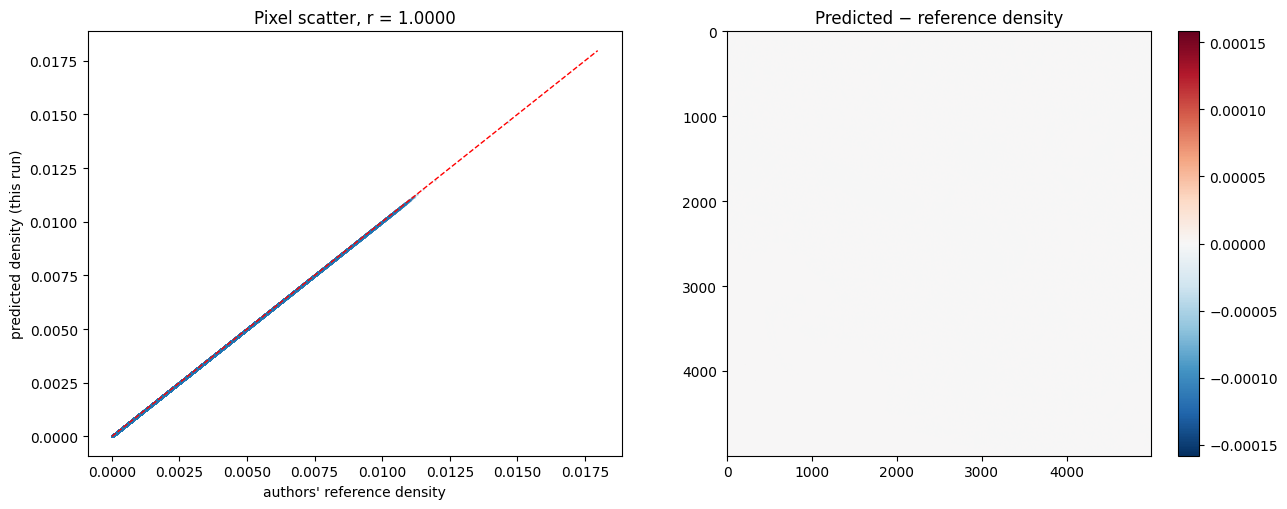

In [ ]:
step = 8  # subsample pixels for the scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].scatter(ref_dens[::step, ::step].ravel(), pred_dens[::step, ::step].ravel(), s=1, alpha=0.15)
lim = max(ref_dens.max(), pred_dens.max())
axes[0].plot([0, lim], [0, lim], "r--", lw=1)
axes[0].set_xlabel("authors' reference density")
axes[0].set_ylabel("predicted density (this run)")
axes[0].set_title(f"Pixel scatter, r = {corr:.4f}")
diff = pred_dens - ref_dens
im = axes[1].imshow(diff, cmap="RdBu_r", vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
axes[1].set_title("Predicted − reference density")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig("/content/comparison_density.png", dpi=110, bbox_inches="tight")
plt.show()


## 12. Interpretation and validation record

**What was executed.** The authors' pretrained RGB counting+segmentation model (pinned commit `6cab24d`) ran on their
own 1 km² example tile with their documented example recipe (256 px patches, stride 224, per-patch standardization,
MAX merge, 0.5 threshold). Outputs were compared with the reference rasters shipped in the same folder.

**How to read the metrics.** The reproduction is faithful if the density correlation is ≈1, segmentation IoU ≈1, and
the tree count (density sum) matches the reference within a small percent — exact byte equality is not expected
across TF versions and CPU/GPU devices. See the table above for the measured values of *this* run; they are also in
`/content/comparison_metrics.csv`.

**What this does and does not show.** This is a single-tile pretrained-inference demonstration. It does not recompute
the paper's dataset-level scores (test F1 0.77, count R² 0.93, height MAE 2.9 m) and does not cover training,
fine-tuning, the height model, or the national-scale pipeline. The example data carry a license notice (printed in
section 3); the repo code license is in the repository (`LICENSE.md`).

**日本語:** 著者の例題タイルに対して学習済みモデルの推論を再現し、同梱の参照予測と定量的に比較しました。単一タイルの実演であり、論文のデータセット全体の精度評価や学習・高さ推定は含みません。


## References and provenance

- Paper: Li, S. et al., "Deep learning enables image-based tree counting, crown segmentation and height prediction at national scale", PNAS Nexus 2(4):pgad076 (2023), DOI [10.1093/pnasnexus/pgad076](https://doi.org/10.1093/pnasnexus/pgad076).
- Code: https://github.com/sizhuoli/TreeCountSegHeight @ `6cab24dad58ffcdb5afb2417b49826e643561fac` — `core2/UNet_attention_segcount.py`, `core2/raster_ana_segcount.py` (`detect_tree_segcount_fi`), `core2/model_manager.py` (`ModelManager`), `core2/frame_info.py` (`image_normalize`), `config/RasterAnalysis.py`, `core2/model_compare.py` (`integrate_count`).
- Weights: ERDA share `https://sid.erda.dk/share_redirect/gS7JX84yvu` (linked from the repo README "Trained models ready for deployment"; zip CRC-verified; RGB member named as in `config/RasterAnalysis.py`).
- Data: example tile + reference predictions from the pinned repo commit, git-blob-SHA1-verified; Danish imagery © Styrelsen for Dataforsyning og Infrastruktur (license note printed in §3).
- Executed on Google Colab; runtime and versions are printed by the cells above (TensorFlow 2.21 / Keras 3.13 era image). The authors' own environment was `tf2151full` (TensorFlow 2.15.1, GPU).

**日本語:** 出典は上記の通りです。論文・コード・重み・データの各バージョンはすべてノートブック内で固定・検証されています。
